In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load the dataset

df = pd.read_csv("../data/raw/OnlineRetail.csv", encoding="ISO-8859-1")

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
# Check the number of rows and columns

df.shape

(541909, 8)

In [8]:
# Display column names

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [9]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [10]:
# Count missing values in each column

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
# Count duplicate rows

df.duplicated().sum()

np.int64(5268)

In [12]:
# Remove duplicate rows

df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Remove duplicate rows

df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(536641, 8)

In [17]:
# Summary statistics for numerical columns

df.describe()

,Quantity,UnitPrice,CustomerID
count,536641.000000,536641.000000,401604.000000
mean,9.620029,4.632656,15281.160818
std,219.130156,97.233118,1714.006089
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13939.000000
50%,3.000000,2.080000,15145.000000
75%,10.000000,4.130000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [18]:
# Keep only rows with positive quantity and positive unit price

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [19]:
df.shape

(524878, 8)

In [20]:
# Convert InvoiceDate from text to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  str           
 1   StockCode    524878 non-null  str           
 2   Description  524878 non-null  str           
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[us]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 36.0 MB


In [22]:
# Create TotalSales column

df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [24]:
# Calculate total revenue

df["TotalSales"].sum()

np.float64(10642110.804000001)

In [25]:
# Display Total Revenue

total_revenue = df["TotalSales"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 10,642,110.80


In [26]:
# Total Orders

total_orders = df["InvoiceNo"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 19960


In [27]:
# Total Customers

total_customers = df["CustomerID"].nunique()

print(f"Total Customers: {total_customers}")

Total Customers: 4338


In [28]:
# Total Products

total_products = df["StockCode"].nunique()

print(f"Total Products: {total_products}")

Total Products: 3922


In [29]:
# Average Order Value

average_order_value = total_revenue / total_orders

print(f"Average Order Value: {average_order_value:.2f}")

Average Order Value: 533.17


In [30]:
# Create a new Month column

df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [31]:
# Calculate monthly sales

monthly_sales = df.groupby("Month")["TotalSales"].sum()

monthly_sales

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: TotalSales, dtype: float64

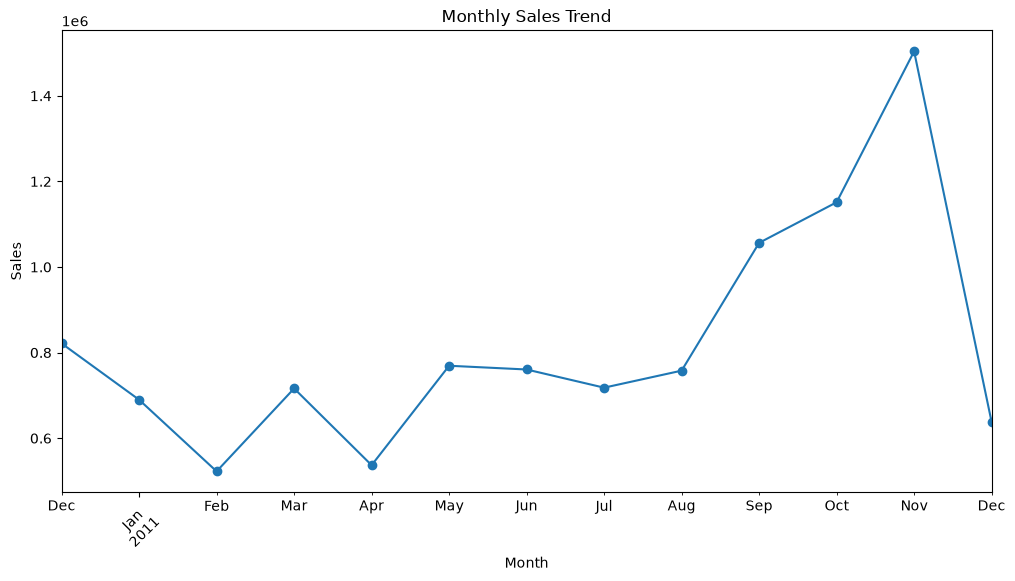

In [32]:
# Plot monthly sales trend

plt.figure(figsize=(12,6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

In [33]:
# Revenue by product

top_products = (
    df.groupby("Description")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: TotalSales, dtype: float64

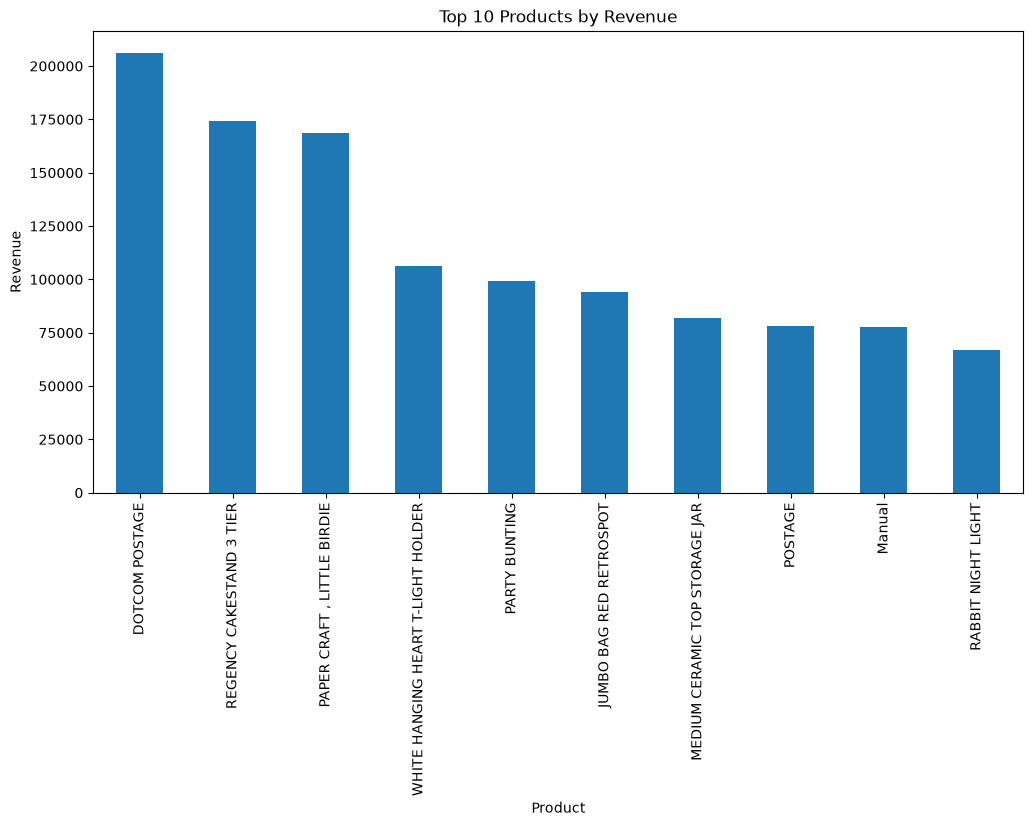

In [34]:
# Plot Top 10 Products

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

In [35]:
# Remove postage charges

df = df[df["Description"] != "DOTCOM POSTAGE"]

In [36]:
top_products = (
    df.groupby("Description")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
Name: TotalSales, dtype: float64

In [37]:
# Top 10 customers by total spending

top_customers = (
    df.groupby("CustomerID")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalSales, dtype: float64

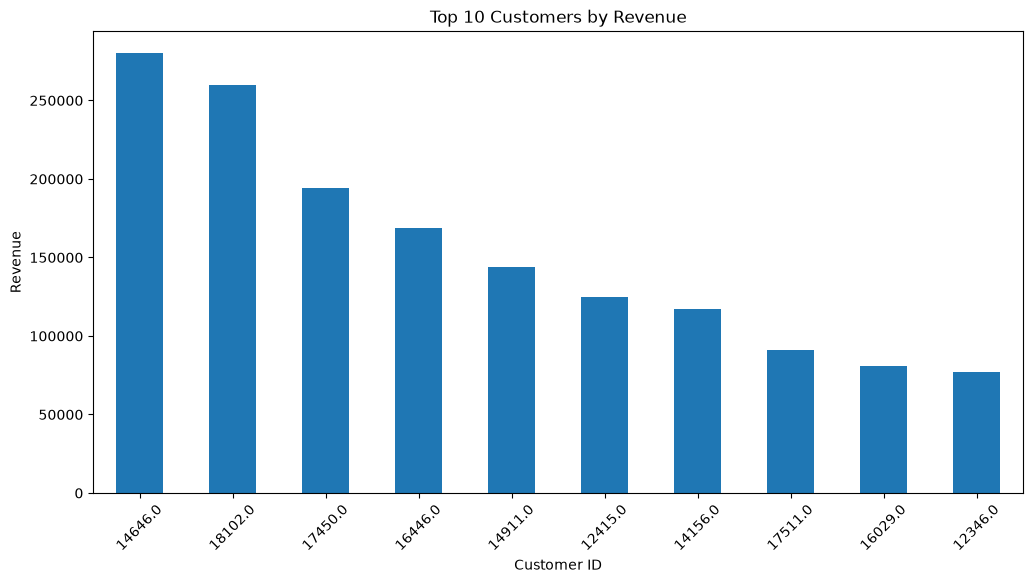

In [38]:
# Plot Top 10 Customers

plt.figure(figsize=(12,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [39]:
# Revenue by country

country_sales = (
    df.groupby("Country")["TotalSales"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    8795495.324
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64

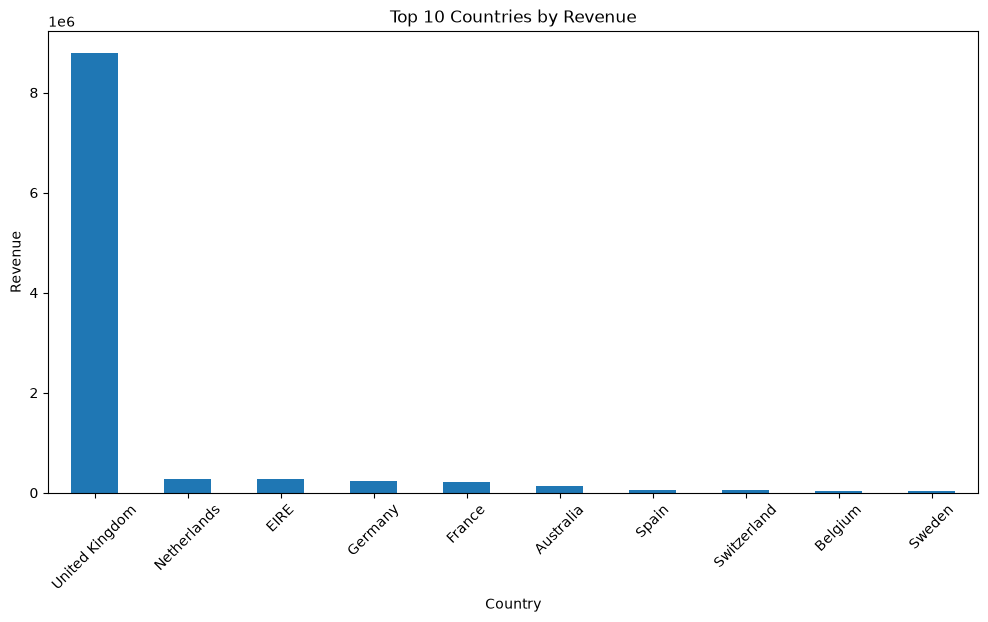

In [40]:
# Plot Top 10 Countries by Revenue

plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [41]:
# Create customer summary

customer_summary = df.groupby("CustomerID").agg({
    "TotalSales": "sum",
    "InvoiceNo": "nunique",
    "Quantity": "sum"
})

customer_summary.columns = [
    "TotalSpent",
    "TotalOrders",
    "TotalQuantity"
]

customer_summary.head()

,TotalSpent,TotalOrders,TotalQuantity
CustomerID,,,
12346.0,77183.60,1,74215
12347.0,4310.00,7,2458
12348.0,1797.24,4,2341
12349.0,1757.55,1,631
12350.0,334.40,1,197


In [42]:
customer_summary.shape

(4338, 3)

In [43]:
customer_summary["TotalSpent"].describe()

count      4338.000000
mean       2045.943415
std        8967.747543
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalSpent, dtype: float64

In [44]:
# Function to assign customer segments

def customer_segment(spending):
    if spending >= 1660.5975:
        return "VIP"
    elif spending >= 668.57:
        return "Loyal"
    elif spending >= 306.4825:
        return "Regular"
    else:
        return "New"

In [45]:
# Create Segment column

customer_summary["Segment"] = customer_summary["TotalSpent"].apply(customer_segment)

customer_summary.head()

,TotalSpent,TotalOrders,TotalQuantity,Segment
CustomerID,,,,
12346.0,77183.60,1,74215,VIP
12347.0,4310.00,7,2458,VIP
12348.0,1797.24,4,2341,VIP
12349.0,1757.55,1,631,VIP
12350.0,334.40,1,197,Regular


In [46]:
customer_summary["Segment"].value_counts()

Segment
VIP        1085
New        1085
Regular    1084
Loyal      1084
Name: count, dtype: int64

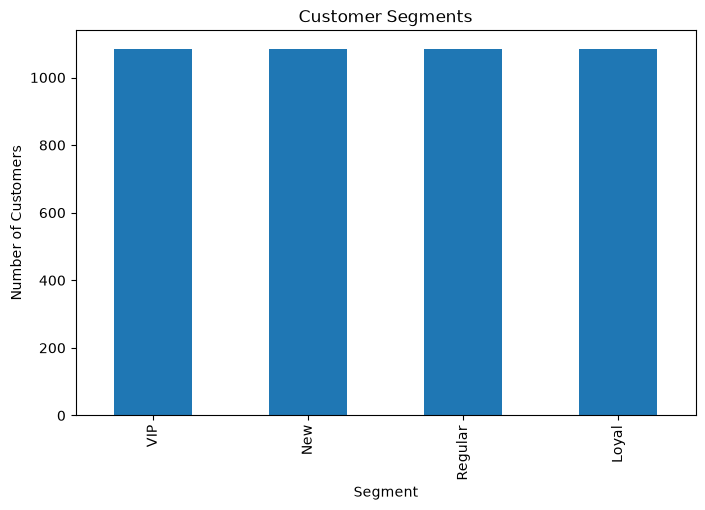

In [47]:
plt.figure(figsize=(8,5))

customer_summary["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/charts/monthly_sales_trend.png'

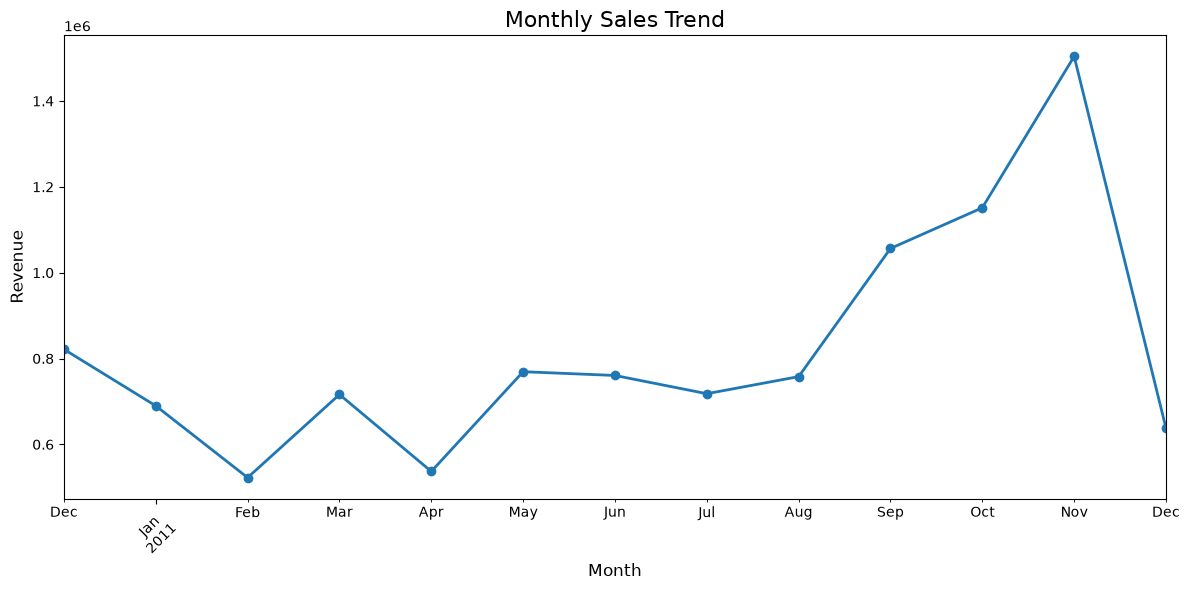

In [48]:
# Monthly Sales Trend

plt.figure(figsize=(12,6))

monthly_sales.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/monthly_sales_trend.png", dpi=300)

plt.show()

In [52]:
import os

os.makedirs("../outputs/charts", exist_ok=True)

FileExistsError: [WinError 183] Cannot create a file when that file already exists: '../outputs/charts'

In [53]:
import os

print(os.path.exists("../outputs"))
print(os.path.isdir("../outputs"))

print(os.path.exists("../outputs/charts"))
print(os.path.isdir("../outputs/charts"))

True
True
True
False


In [54]:
plt.savefig("../outputs/charts/monthly_sales_trend.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [55]:
monthly_sales.head()

Month
2010-12    821452.730
2011-01    689811.610
2011-02    522545.560
2011-03    716215.260
2011-04    536968.491
Freq: M, Name: TotalSales, dtype: float64

In [56]:
monthly_sales.shape

(13,)

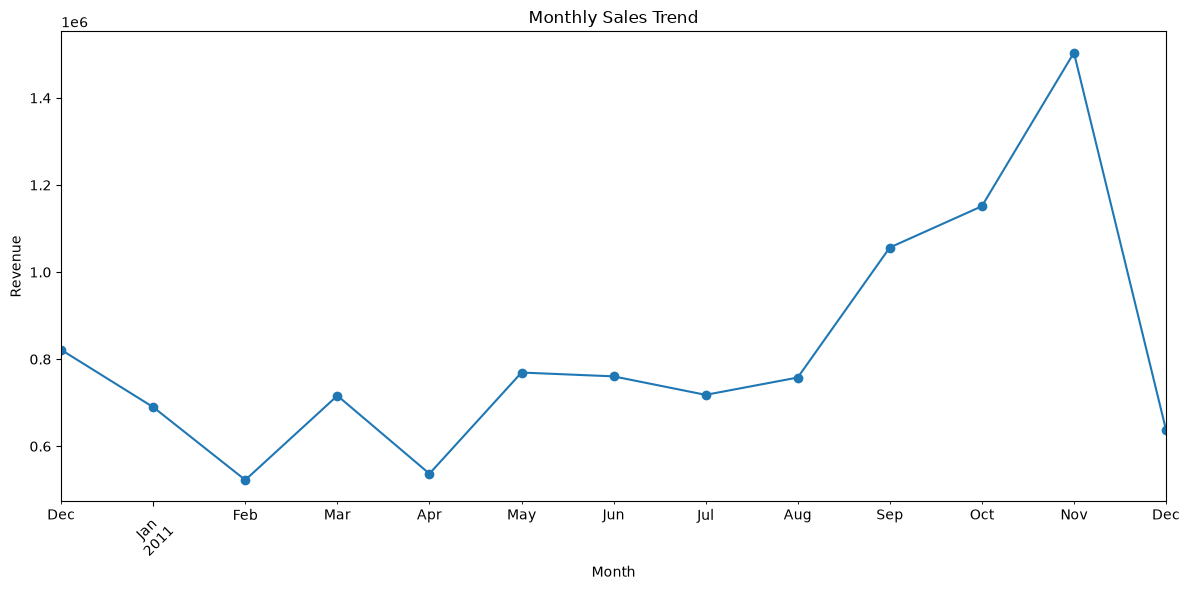

In [57]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [58]:
plt.savefig("../outputs/charts/monthly_sales_trend.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [59]:
monthly_sales.head()

Month
2010-12    821452.730
2011-01    689811.610
2011-02    522545.560
2011-03    716215.260
2011-04    536968.491
Freq: M, Name: TotalSales, dtype: float64

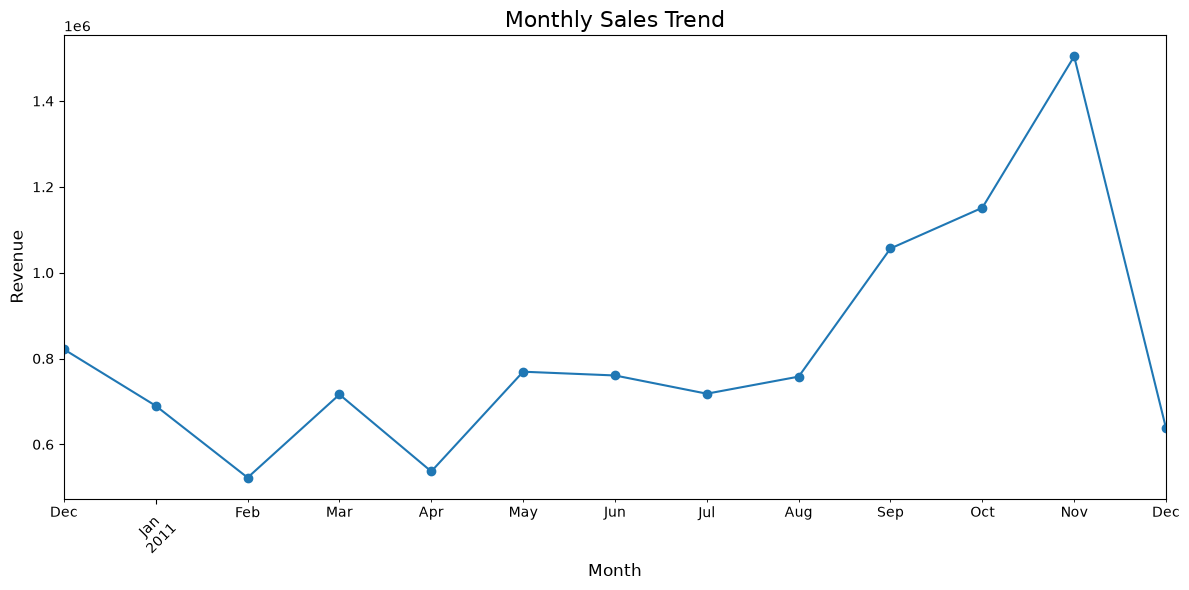

In [60]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [61]:
plt.savefig("../outputs/charts/monthly_sales_trend.png", dpi=300)

<Figure size 640x480 with 0 Axes>

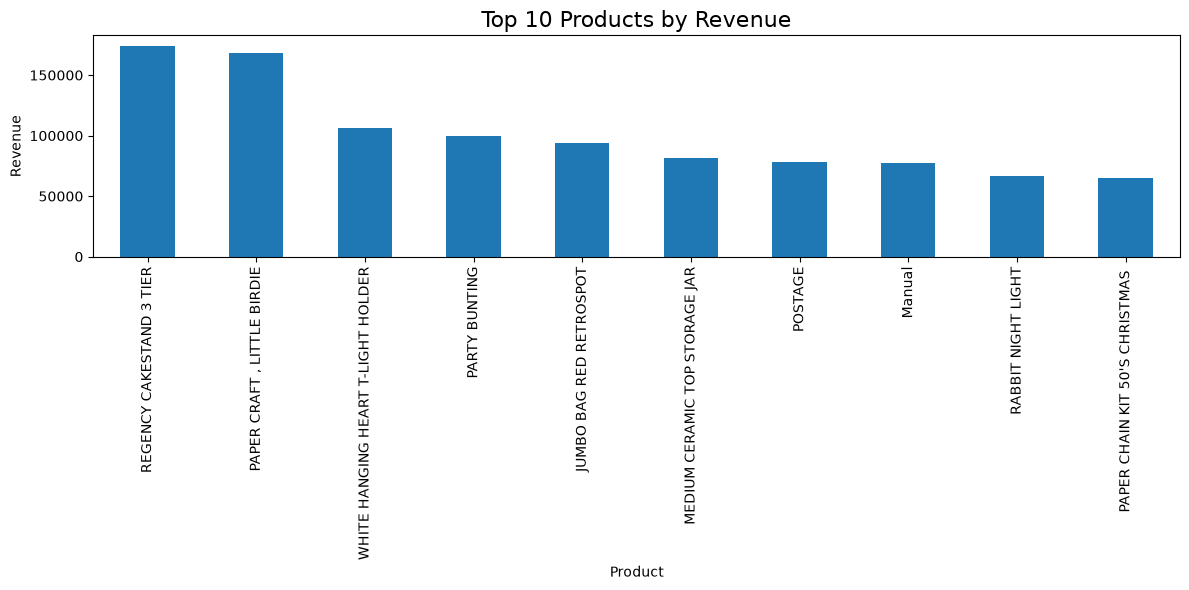

In [62]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("../outputs/charts/top_10_products.png", dpi=300)

plt.show()

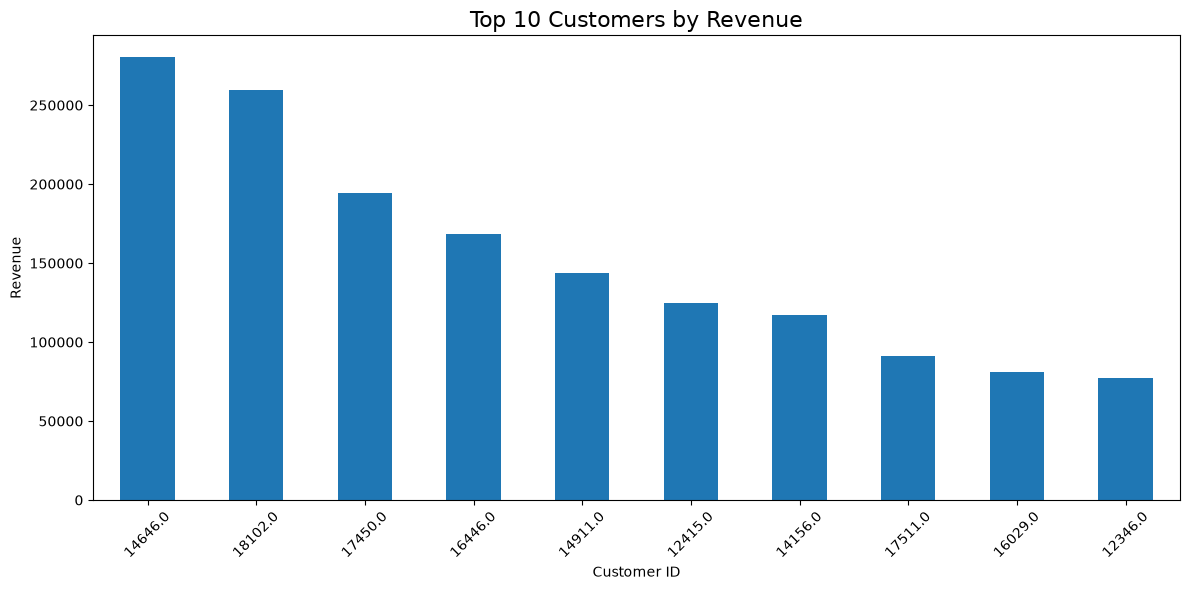

In [63]:
plt.figure(figsize=(12,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue", fontsize=16)
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/top_10_customers.png", dpi=300)

plt.show()

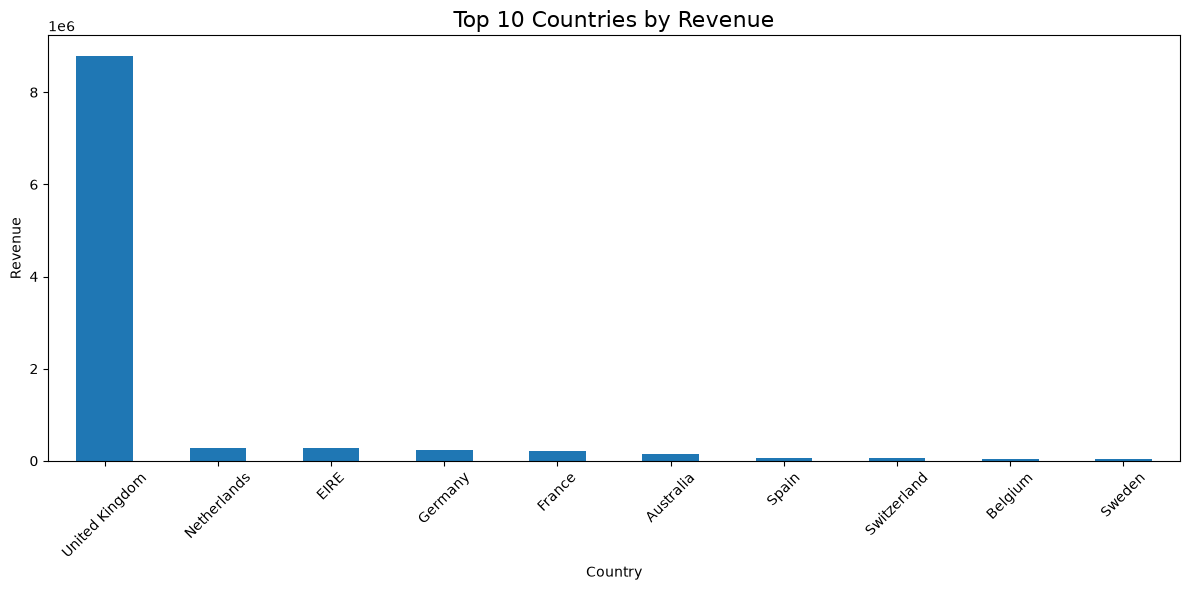

In [64]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/top_10_countries.png", dpi=300)

plt.show()

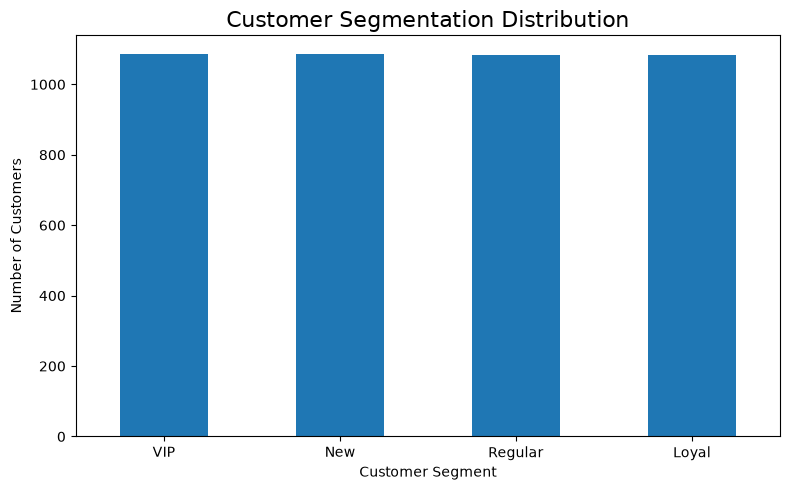

In [65]:
plt.figure(figsize=(8,5))

customer_summary["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segmentation Distribution", fontsize=16)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../outputs/charts/customer_segments.png", dpi=300)

plt.show()

In [66]:
# Import dashboard libraries

import matplotlib.pyplot as plt

In [67]:
# KPI values

total_revenue = df["TotalSales"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
average_order_value = total_revenue / total_orders


print("Revenue:", round(total_revenue,2))
print("Orders:", total_orders)
print("Customers:", total_customers)
print("Products:", total_products)
print("Average Order Value:", round(average_order_value,2))

Revenue: 10435862.03
Orders: 19960
Customers: 4338
Products: 3921
Average Order Value: 522.84


In [68]:
fig = plt.figure(figsize=(16,10))

fig.suptitle(
    "Customer Sales Analysis Dashboard",
    fontsize=20
)

plt.show()

<Figure size 1600x1000 with 0 Axes>

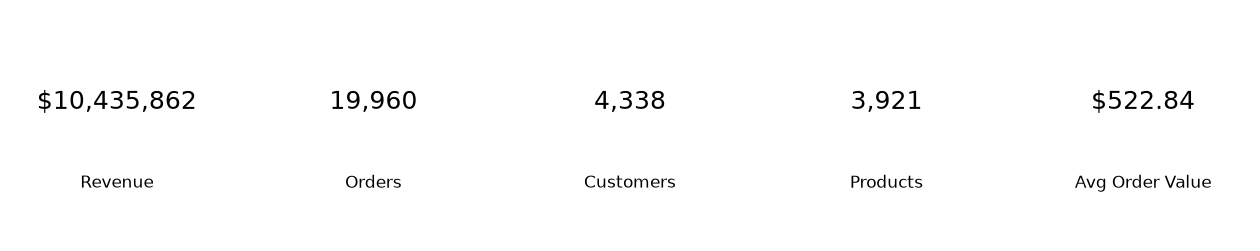

In [69]:
# Create KPI cards

fig, axes = plt.subplots(1, 5, figsize=(16,3))

kpis = [
    ("Revenue", f"${total_revenue:,.0f}"),
    ("Orders", f"{total_orders:,}"),
    ("Customers", f"{total_customers:,}"),
    ("Products", f"{total_products:,}"),
    ("Avg Order Value", f"${average_order_value:,.2f}")
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(
        0.5, 0.6,
        value,
        ha="center",
        va="center",
        fontsize=18
    )
    
    ax.text(
        0.5, 0.25,
        title,
        ha="center",
        va="center",
        fontsize=12
    )
    
    ax.axis("off")

plt.show()

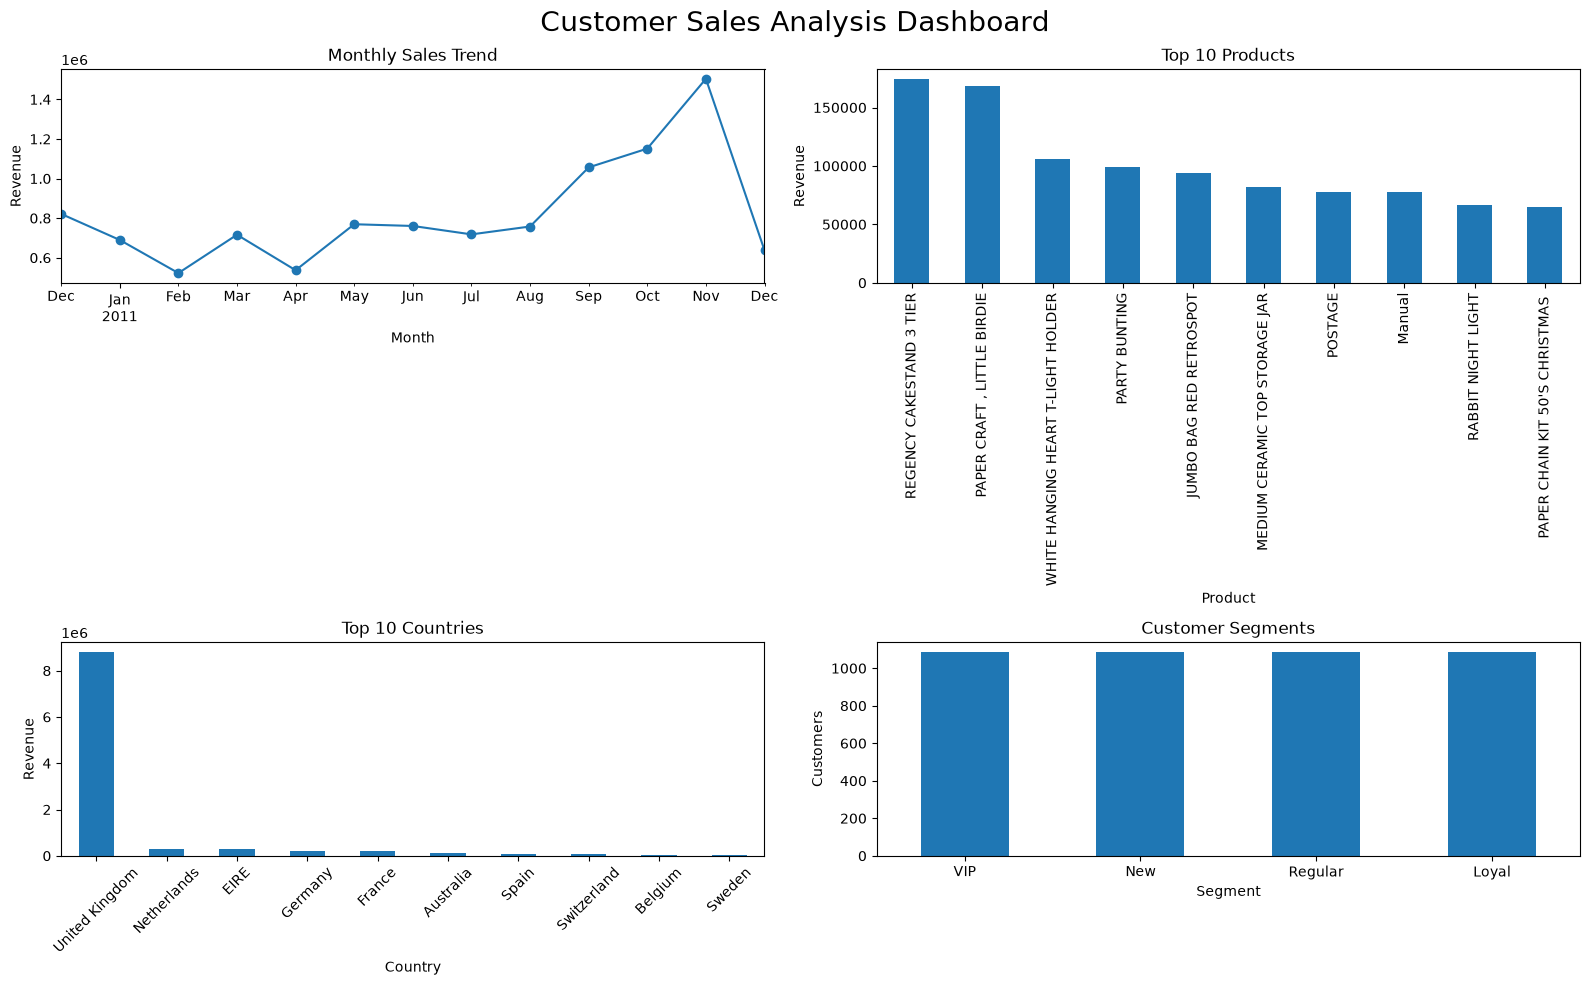

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

fig.suptitle(
    "Customer Sales Analysis Dashboard",
    fontsize=20
)

# 1. Monthly Sales Trend

monthly_sales.plot(
    ax=axes[0,0],
    marker="o"
)

axes[0,0].set_title("Monthly Sales Trend")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue")


# 2. Top Products

top_products.plot(
    kind="bar",
    ax=axes[0,1]
)

axes[0,1].set_title("Top 10 Products")
axes[0,1].set_xlabel("Product")
axes[0,1].set_ylabel("Revenue")
axes[0,1].tick_params(axis="x", rotation=90)


# 3. Top Countries

country_sales.head(10).plot(
    kind="bar",
    ax=axes[1,0]
)

axes[1,0].set_title("Top 10 Countries")
axes[1,0].set_xlabel("Country")
axes[1,0].set_ylabel("Revenue")
axes[1,0].tick_params(axis="x", rotation=45)


# 4. Customer Segments

customer_summary["Segment"].value_counts().plot(
    kind="bar",
    ax=axes[1,1]
)

axes[1,1].set_title("Customer Segments")
axes[1,1].set_xlabel("Segment")
axes[1,1].set_ylabel("Customers")
axes[1,1].tick_params(axis="x", rotation=0)


plt.tight_layout()

plt.show()

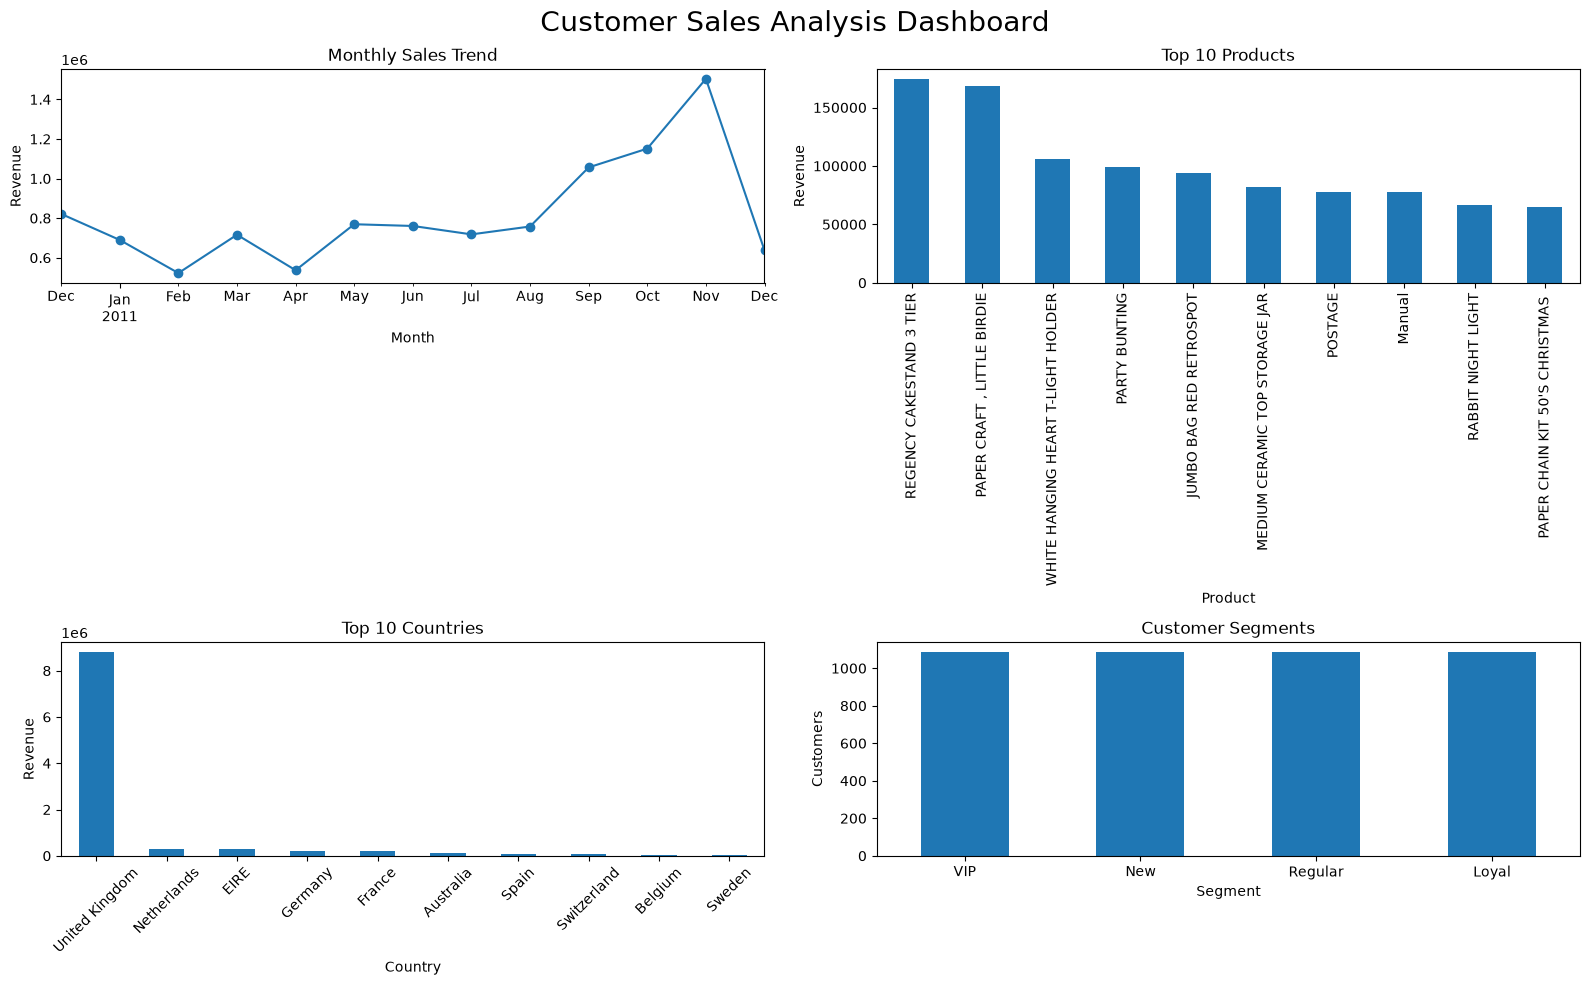

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

fig.suptitle(
    "Customer Sales Analysis Dashboard",
    fontsize=20
)

# 1. Monthly Sales Trend

monthly_sales.plot(
    ax=axes[0,0],
    marker="o"
)

axes[0,0].set_title("Monthly Sales Trend")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue")


# 2. Top Products

top_products.plot(
    kind="bar",
    ax=axes[0,1]
)

axes[0,1].set_title("Top 10 Products")
axes[0,1].set_xlabel("Product")
axes[0,1].set_ylabel("Revenue")
axes[0,1].tick_params(axis="x", rotation=90)


# 3. Top Countries

country_sales.head(10).plot(
    kind="bar",
    ax=axes[1,0]
)

axes[1,0].set_title("Top 10 Countries")
axes[1,0].set_xlabel("Country")
axes[1,0].set_ylabel("Revenue")
axes[1,0].tick_params(axis="x", rotation=45)


# 4. Customer Segments

customer_summary["Segment"].value_counts().plot(
    kind="bar",
    ax=axes[1,1]
)

axes[1,1].set_title("Customer Segments")
axes[1,1].set_xlabel("Segment")
axes[1,1].set_ylabel("Customers")
axes[1,1].tick_params(axis="x", rotation=0)
plt.tight_layout()

plt.savefig(
    "../outputs/dashboard/sales_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Customer Sales Analysis & Customer Segmentation

## Project Objective

Analyze online retail transaction data to understand sales performance, identify top-performing products and customers, and segment customers based on spending behavior.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

# 1. Import Libraries

# 2. Load Dataset

# 3. Data Exploration

# 4. Data Cleaning

# 5. Feature Engineering

# 6. Exploratory Data Analysis

# 7. Customer Segmentation

# 8. Business Insights

# 9. Conclusion

# Conclusion

This project analyzed over 500,000 retail transactions to identify sales trends, top-performing products, valuable customers, and customer spending segments.

Key outcomes:

- Identified revenue trends over time.
- Found the highest revenue-generating products and customers.
- Analyzed country-wise sales performance.
- Segmented customers into VIP, Loyal, Regular, and New categories.

The analysis provides actionable insights that can support marketing strategies, customer retention, and sales optimization.